In [3]:
from Calibration import *
from Integrate_and_save import *
import tkinter as tk
from tkinter import filedialog
import os
import pyFAI
# pyFAI.use_opencl = False

root = tk.Tk()
root.withdraw()  # Hide the root window
root.attributes("-topmost", True)  # Keep the dialog on top

''

In [5]:
calibrant = 'ito_calibrant.D'
ponifile = 'ITO_test.poni'

giwaxsCalibration(ponifile, calibrant)

Launching pyFAI calibration GUI. This will take a few seconds...


In [4]:
ITO_image_path = filedialog.askopenfilename(
    title="Select the ITO image",
    filetypes=[("All files", "*.*")]
)


D:/MAPbI3_nanofibers_S4_ITO__refined.poni
Detector Pilatus 1M	 PixelSize= 172µm, 172µm	 BottomRight (3)
Wavelength= 1.239842e-10 m
SampleDetDist= 1.944786e-01 m	PONI= 8.804020e-02, 4.538463e-02 m	rot1=-0.644276  rot2=0.013080  rot3=3.141593 rad
DirectBeamDist= 243.261 mm	Center: x=1113.251, y=530.360 pix	Tilt= 36.921° tiltPlanRotation= 1.248° 𝛌= 1.240Å


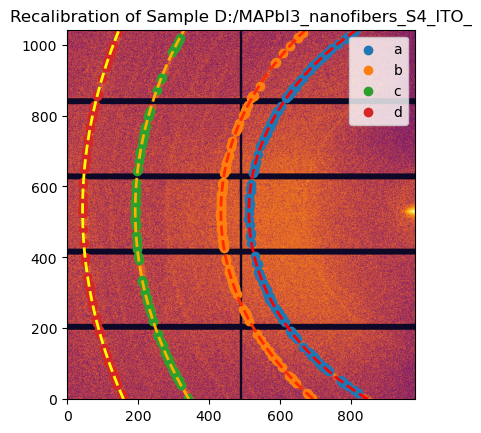

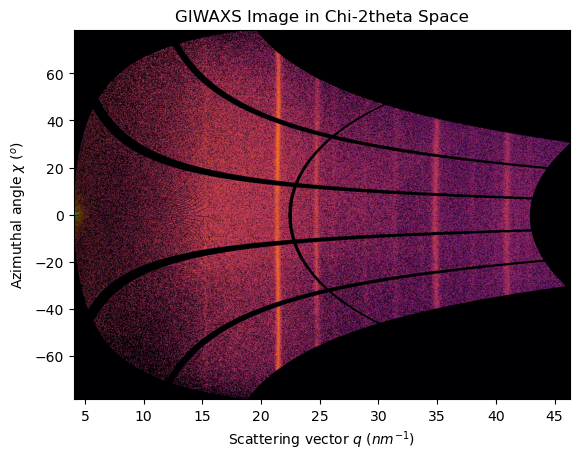

In [6]:




image_path = ITO_image_path
sample_name = image_path.split("\\")[-1].split(".")[0]  # Extract sample name from image path
initial_poni = r"nanofibers_init.poni"
calibrant_file = r"ito_calibrant_refine.D"

if not image_path.endswith(".tif"):
    refined_poni = image_path + "_refined.poni"
else:
    refined_poni = image_path.replace(".tif", "_refined.poni")
print(refined_poni)
refine_calibration(sample_name, image_path, initial_poni, calibrant_file, refined_poni)
plot_Chi_2theta(image_path, refined_poni) #sanity check, the lines should be straight and vertical

In [7]:
folder_path = filedialog.askdirectory(
    title="Select the folder with images to integrate",
    mustexist=True
)

Integrating TIFs: 100%|██████████| 859/859 [01:14<00:00, 11.54it/s]


Saved integrated GIWAXS data to D:/MAPbI3_nanofibers_S4_ITO__GIWAXS_raw.npz


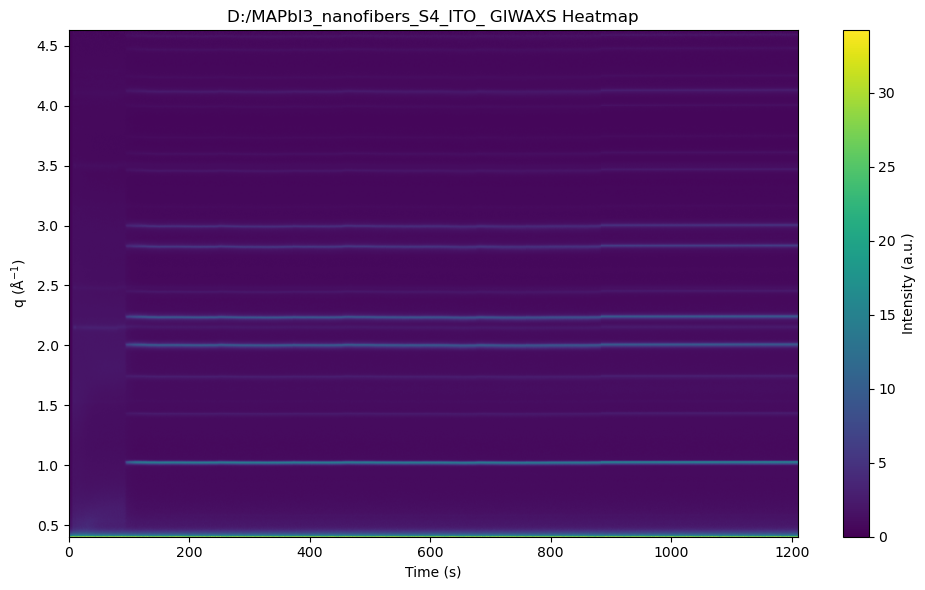

<Figure size 640x480 with 0 Axes>

In [9]:


# folder_path  = r'k:\printz_Apr2024\MAPI_YL\MAPI_1pct_AVACl_S1_18_5min'
# # Integrate the refined calibration
# method = ("full", "csr", "opencl")
# integrated_data = integrate_giwaxs(folder_path, refined_poni, method)
#if you don't have a GPU or don't want to use opencl, you can use the following line instead:
integrated_data = integrate_giwaxs(folder_path, refined_poni)
save_and_plot(*integrated_data, folder_path, sample_name)

In [10]:
import glob
def load_GIWAXS_npz(npz_file_folder):
    """
    Load previously saved GIWAXS q, time, intensity arrays from .npz.
    """
    # Find the first .npz file in the folder
    npz_files = glob.glob(os.path.join(npz_file_folder, "*.npz"))
    if not npz_files:
        raise FileNotFoundError(f"No .npz files found in {npz_file_folder}")
    npz_file_path = npz_files[0]
    data = np.load(npz_file_path)
    return data["q"], data["time"], data["intensity"]

q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")
print(f"{q}, {time}, {intensity}")
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(intensity.T, aspect='auto', extent=[time[0], time[-1], q[0], q[-1]], origin='lower', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Time')
plt.ylabel('q')
plt.title('GIWAXS Intensity Heatmap')
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\M'
<>:14: SyntaxWarning: invalid escape sequence '\M'
C:\Users\raglo\AppData\Local\Temp\ipykernel_30184\581425105.py:14: SyntaxWarning: invalid escape sequence '\M'
  q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")
C:\Users\raglo\AppData\Local\Temp\ipykernel_30184\581425105.py:14: SyntaxWarning: invalid escape sequence '\M'
  q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")


FileNotFoundError: No .npz files found in K:\MAPbI3_nanofibers_S1\GIWAXS

<>:42: SyntaxWarning: invalid escape sequence '\M'
<>:42: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Aj\AppData\Local\Temp\ipykernel_36368\4047504471.py:42: SyntaxWarning: invalid escape sequence '\M'
  q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")


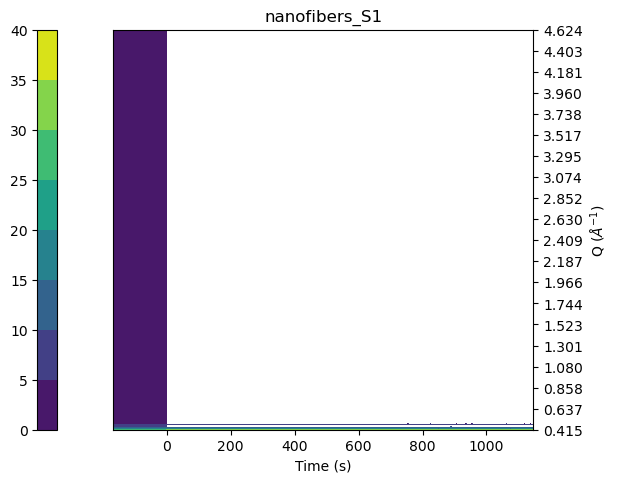

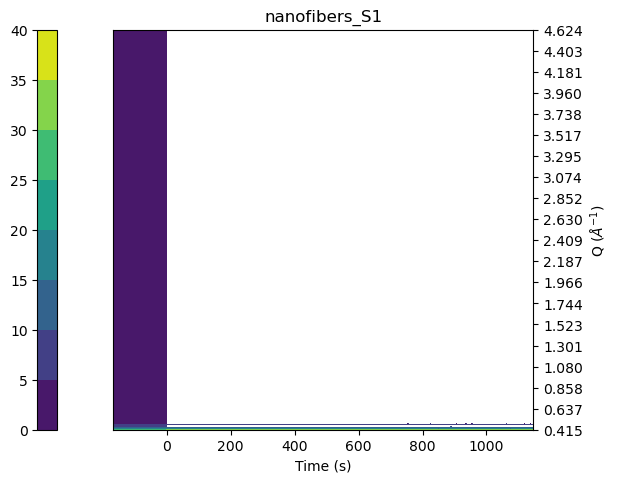

In [ ]:
def plotGIWAXS(sample_name, q, frame_time, intensity):

    '''
    Parameters
    ----------
    sample_name : str,
        name of the sample. Default is the name under which scan is saved.
    save_path : path object
        where the output is saved.


    Returns
    -------
    Contour plot

    '''

    # create an empty figure with the following dimensions
    fig = plt.figure(figsize=(7, 5))
    left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
    ax = fig.add_axes([left, bottom, width, height])

    # add the contour plot and a colorbar
    cp = ax.contourf(frame_time, q, intensity.T)
    plt.colorbar(cp, location='left')

    # define axis names, ticks, etc.
    q_min, q_max = (q[0], q[-1])
    y_ticks = np.linspace(q_min, q_max, 20)  # number of tickmarks
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(r'Q $(\AA^{-1})$')
    ax.set_yticks(y_ticks)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    ax.set_ylim(q_min, q_max)
    ax.set_title(sample_name)
    # plt.show(block=False)
    # plt.pause(1)

    return fig
sample_name = "nanofibers_S1"
q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")
plotGIWAXS(sample_name, q, time, intensity)

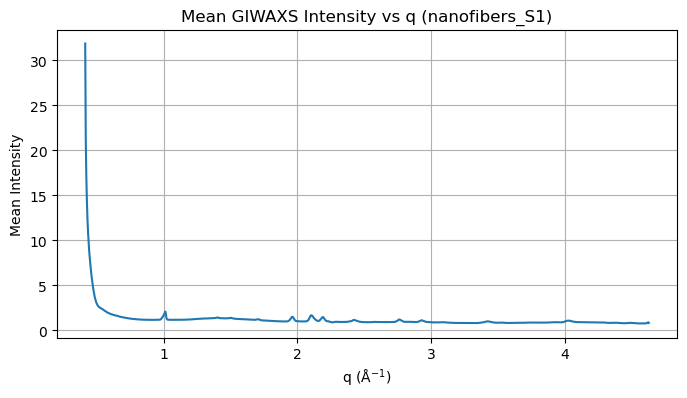

In [10]:
import matplotlib.pyplot as plt

mean_q_profile = np.mean(intensity, axis=0)

plt.figure(figsize=(8, 4))
plt.plot(q, mean_q_profile)
plt.xlabel("q (Å$^{-1}$)")
plt.ylabel("Mean Intensity")
plt.title("Mean GIWAXS Intensity vs q (nanofibers_S1)")
plt.grid(True)
plt.show()
